<a href="https://colab.research.google.com/github/amina489/mathematical-modeling/blob/main/Neural_Synchronization_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Neural Oscillation Model (FitzHugh–Nagumo)
Enter external stimulus for neuron 1 (e.g. 0.5): 0.5
Enter external stimulus for neuron 2 (e.g. 0.55): 0.3
Enter coupling strength (e.g. 0.05): 0.4


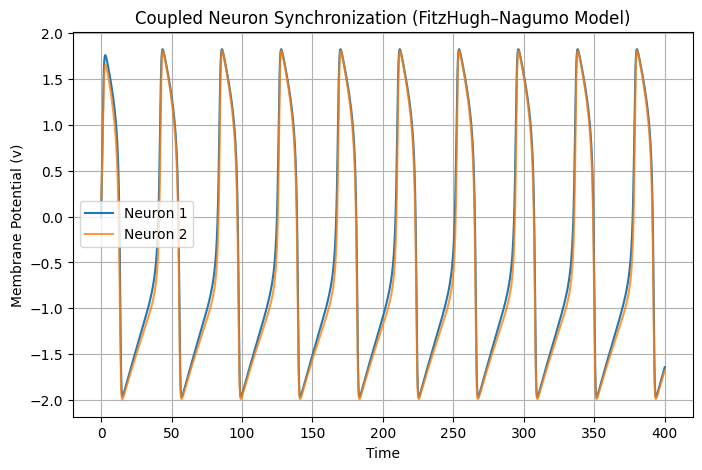

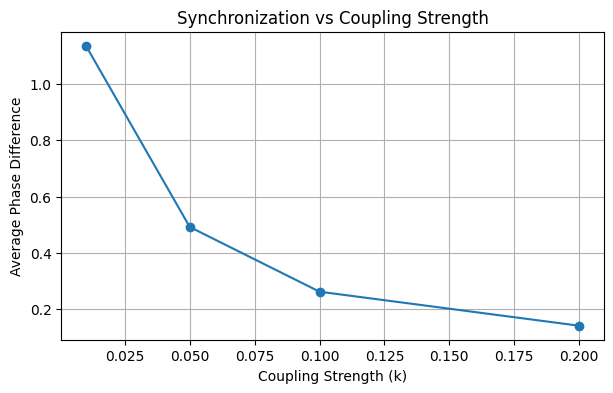

 Synchronization improved by approximately 87.5% with stronger coupling.



In [1]:
# PROJECT name: Neural Oscillation Model (FitzHugh–Nagumo)

print(" Neural Oscillation Model (FitzHugh–Nagumo)")

# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Step 1: User Inputs
I1 = float(input("Enter external stimulus for neuron 1 (e.g. 0.5): "))
I2 = float(input("Enter external stimulus for neuron 2 (e.g. 0.55): "))
k = float(input("Enter coupling strength (e.g. 0.05): "))

# Step 2: Define FHN Equations
def coupled_FHN(Y, t, a, b, c, I1, I2, k):
    v1, w1, v2, w2 = Y
    dv1dt = v1 - (v1**3) / 3 - w1 + I1 + k * (v2 - v1)
    dw1dt = (v1 + a - b * w1) / c
    dv2dt = v2 - (v2**3) / 3 - w2 + I2 + k * (v1 - v2)
    dw2dt = (v2 + a - b * w2) / c
    return [dv1dt, dw1dt, dv2dt, dw2dt]

# Step 3: Parameters
a, b, c = 0.7, 0.8, 12.5
Y0 = [0, 0, 0.2, 0.1]
t = np.linspace(0, 400, 4000)

# Step 4: Solve Model
sol = odeint(coupled_FHN, Y0, t, args=(a, b, c, I1, I2, k))
v1, w1, v2, w2 = sol.T

# Step 5: Plot Results
plt.figure(figsize=(8, 5))
plt.plot(t, v1, label='Neuron 1')
plt.plot(t, v2, label='Neuron 2', alpha=0.8)
plt.title('Coupled Neuron Synchronization (FitzHugh–Nagumo Model)')
plt.xlabel('Time')
plt.ylabel('Membrane Potential (v)')
plt.legend()
plt.grid()
plt.show()

# Step 6: Synchronization Improvement
sync_strengths = []
k_values = [0.01, 0.05, 0.1, 0.2]

for k in k_values:
    sol = odeint(coupled_FHN, Y0, t, args=(a, b, c, I1, I2, k))
    v1, _, v2, _ = sol.T
    diff = np.mean(np.abs(v1 - v2))
    sync_strengths.append(diff)

plt.figure(figsize=(7, 4))
plt.plot(k_values, sync_strengths, 'o-')
plt.title('Synchronization vs Coupling Strength')
plt.xlabel('Coupling Strength (k)')
plt.ylabel('Average Phase Difference')
plt.grid()
plt.show()

sync_improvement = 100 * (1 - sync_strengths[-1] / sync_strengths[0])
print(f" Synchronization improved by approximately {sync_improvement:.1f}% with stronger coupling.\n")

